In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("GPUs visible:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1784094848.578381  131902 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784094848.610035  131902 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784094849.353020  131902 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPUs visible: []


E0000 00:00:1784094849.862052  131902 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1784094849.862073  131902 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1784094849.862081  131902 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1784094849.862087  131902 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1784094849.862089  131902 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: kabi-ROG-Strix-G16
I0000 00:00:1784094849.862092  131902 cuda_diagnostics.cc:183] hostname: kabi-ROG-Strix-G16
I0000 00:00:1784094849.862158  131902 cuda_diagnostics.cc:190] libcuda reported version is: 610.43.2
I0000 00:00:1784094849.862170  131902 cuda_diagnostics.

In [2]:

raw = pd.read_csv(
    '/home/kabi/Semester-7-/DL/individual+household+electric+power+consumption/household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)
raw['Datetime'] = pd.to_datetime(raw['Date'] + ' ' + raw['Time'], format='%d/%m/%Y %H:%M:%S')
raw.set_index('Datetime', inplace=True)
raw['Global_active_power'] = raw['Global_active_power'].astype(float)

# Resample minute-level readings to hourly averages
data = raw[['Global_active_power']].resample('h').mean()
data.dropna(inplace=True)

print(data.head())
print(f"Data shape: {data.shape}")

                     Global_active_power
Datetime                                
2006-12-16 17:00:00             4.222889
2006-12-16 18:00:00             3.632200
2006-12-16 19:00:00             3.400233
2006-12-16 20:00:00             3.268567
2006-12-16 21:00:00             3.056467
Data shape: (34168, 1)


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['Global_active_power']])

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24  # past 24 hours -> predict next hour
X, y = create_sequences(scaled_data, seq_length)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (27315, 24, 1)
X_test shape: (6829, 24, 1)


In [4]:
#RNN Model
def build_rnn_model(seq_length):
    model = Sequential([
        SimpleRNN(50, activation='relu', input_shape=(seq_length, 1)),
        Dense(25, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

rnn_model = build_rnn_model(seq_length)
print("RNN Model Summary:")
rnn_model.summary()
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
rnn_pred = rnn_model.predict(X_test)
rnn_rmse = np.sqrt(mean_squared_error(y_test, rnn_pred))
rnn_mae = mean_absolute_error(y_test, rnn_pred)
print(f"RNN RMSE: {rnn_rmse:.4f}, MAE: {rnn_mae:.4f}")

RNN Model Summary:


/home/kabi/.conda/envs/llm/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,308 (16.83 KB)

 Trainable params: 4,308 (16.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0105 - mae: 0.0711 - val_loss: 0.0078 - val_mae: 0.0629
Epoch 2/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0094 - mae: 0.0671 - val_loss: 0.0075 - val_mae: 0.0574
Epoch 3/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0093 - mae: 0.0662 - val_loss: 0.0078 - val_mae: 0.0579
Epoch 4/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0091 - mae: 0.0652 - val_loss: 0.0076 - val_mae: 0.0623
Epoch 5/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0091 - mae: 0.0656 - val_loss: 0.0071 - val_mae: 0.0591
Epoch 6/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0091 - mae: 0.0652 - val_loss: 0.0074 - val_mae: 0.0572
Epoch 7/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0091 - mae: 0.0652 - val_loss: 0.0072 - val_mae: 0.0573
Epoch 8/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0090 - mae: 0.0650 - val_loss: 0.0072 - val_mae: 0.0572
Epoch 9/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

W0000 00:00:1784094901.955174  131902 graph_view.cc:850] No registered '' OpKernel for CPU devices compatible with node {{node sequential_1/simple_rnn_1/while/body/_1/sequential_1/simple_rnn_1/while/simple_rnn_cell_1/Relu}}
	.  Registered:  <no registered kernels>

E0000 00:00:1784094901.957691  131902 tfg_optimizer_hook.cc:135] tfg_optimizer{any(tfg-consolidate-attrs,tfg-toposort,tfg-shape-inference{graph-version=0},tfg-prepare-attrs-export)} failed: INVALID_ARGUMENT: Node sequential_1/simple_rnn_1/while/body/_1/sequential_1/simple_rnn_1/while/simple_rnn_cell_1/Relu has an empty op name
	when importing GraphDef to MLIR module in GrapplerHook
E0000 00:00:1784094901.959847  131902 meta_optimizer.cc:967] remapper failed: NOT_FOUND: Op type not registered '' in binary running on kabi-ROG-Strix-G16. Make sure the Op and Kernel are registered in the binary running in this process. Note that if you are loading a saved graph which used ops from tf.contrib (e.g. `tf.contrib.resampler`), access

RNN RMSE: 0.0801, MAE: 0.0564


## 3. LSTM Model

In [5]:
def build_lstm_model(seq_length):
    model = Sequential([
        LSTM(50, activation='relu', input_shape=(seq_length, 1)),
        Dense(25, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

lstm_model = build_lstm_model(seq_length)
print("LSTM Model Summary:")
lstm_model.summary()

# Train LSTM
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Predictions
lstm_pred = lstm_model.predict(X_test)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_mae = mean_absolute_error(y_test, lstm_pred)
print(f"LSTM RMSE: {lstm_rmse:.4f}, MAE: {lstm_mae:.4f}")

LSTM Model Summary:


/home/kabi/.conda/envs/llm/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,108 (47.30 KB)

 Trainable params: 12,108 (47.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0127 - mae: 0.0827 - val_loss: 0.0089 - val_mae: 0.0752
Epoch 2/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0098 - mae: 0.0695 - val_loss: 0.0076 - val_mae: 0.0614
Epoch 3/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0096 - mae: 0.0681 - val_loss: 0.0075 - val_mae: 0.0611
Epoch 4/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0095 - mae: 0.0675 - val_loss: 0.0081 - val_mae: 0.0692
Epoch 5/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0094 - mae: 0.0670 - val_loss: 0.0078 - val_mae: 0.0659
Epoch 6/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0093 - mae: 0.0668 - val_loss: 0.0075 - val_mae: 0.0581
Epoch 7/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0093 - mae: 0.0664 - val_loss: 0.0074 - val_mae: 0.0586
Epoch 8/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0092 - mae: 0.0660 - val_loss: 0.0076 - val_mae: 0.0624
Epoch 9/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

## 4. Stacked LSTM Model

In [6]:
def build_stacked_lstm_model(seq_length):
    model = Sequential([
        LSTM(100, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        LSTM(50, activation='relu', return_sequences=True),
        Dropout(0.2),
        LSTM(25, activation='relu'),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model
stacked_lstm_model = build_stacked_lstm_model(seq_length)
print("Stacked LSTM Model Summary:")
stacked_lstm_model.summary()
stacked_lstm_history = stacked_lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
stacked_lstm_pred = stacked_lstm_model.predict(X_test)
stacked_lstm_rmse = np.sqrt(mean_squared_error(y_test, stacked_lstm_pred))
stacked_lstm_mae = mean_absolute_error(y_test, stacked_lstm_pred)
print(f"Stacked LSTM RMSE: {stacked_lstm_rmse:.4f}, MAE: {stacked_lstm_mae:.4f}")

Stacked LSTM Model Summary:


/home/kabi/.conda/envs/llm/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,683 (311.26 KB)

 Trainable params: 79,683 (311.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0198 - mae: 0.1100 - val_loss: 0.0137 - val_mae: 0.0869
Epoch 2/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0156 - mae: 0.0941 - val_loss: 0.0093 - val_mae: 0.0687
Epoch 3/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0125 - mae: 0.0818 - val_loss: 0.0091 - val_mae: 0.0631
Epoch 4/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0114 - mae: 0.0766 - val_loss: 0.0078 - val_mae: 0.0638
Epoch 5/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0108 - mae: 0.0743 - val_loss: 0.0080 - val_mae: 0.0620
Epoch 6/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0106 - mae: 0.0733 - val_loss: 0.0075 - val_mae: 0.0574
Epoch 7/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0102 - mae: 0.0712 - val_loss: 0.0074 - val_mae: 0.0617
Epoch 8/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0100 - mae: 0.0705 - val_loss: 0.0075 - val_mae: 0.0615
Epoch 9/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - lo

## 5. GRU Model

In [7]:
def build_gru_model(seq_length):
    model = Sequential([
        GRU(50, activation='relu', input_shape=(seq_length, 1)),
        Dense(25, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

gru_model = build_gru_model(seq_length)
print("GRU Model Summary:")
gru_model.summary()

# Train GRU
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Predictions
gru_pred = gru_model.predict(X_test)
gru_rmse = np.sqrt(mean_squared_error(y_test, gru_pred))
gru_mae = mean_absolute_error(y_test, gru_pred)
print(f"GRU RMSE: {gru_rmse:.4f}, MAE: {gru_mae:.4f}")

GRU Model Summary:


/home/kabi/.conda/envs/llm/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,658 (37.73 KB)

 Trainable params: 9,658 (37.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0110 - mae: 0.0749 - val_loss: 0.0085 - val_mae: 0.0620
Epoch 2/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0103 - mae: 0.0712 - val_loss: 0.0085 - val_mae: 0.0679
Epoch 3/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0102 - mae: 0.0709 - val_loss: 0.0084 - val_mae: 0.0647
Epoch 4/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0102 - mae: 0.0706 - val_loss: 0.0083 - val_mae: 0.0623
Epoch 5/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0101 - mae: 0.0702 - val_loss: 0.0089 - val_mae: 0.0731
Epoch 6/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0099 - mae: 0.0693 - val_loss: 0.0078 - val_mae: 0.0628
Epoch 7/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0094 - mae: 0.0670 - val_loss: 0.0077 - val_mae: 0.0595
Epoch 8/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0093 - mae: 0.0663 - val_loss: 0.0074 - val_mae: 0.0591
Epoch 9/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - lo


Model Comparison:
          Model      RMSE       MAE
0           RNN  0.080077  0.056376
1          LSTM  0.078561  0.053036
2  Stacked LSTM  0.078100  0.056562
3           GRU  0.078241  0.055169


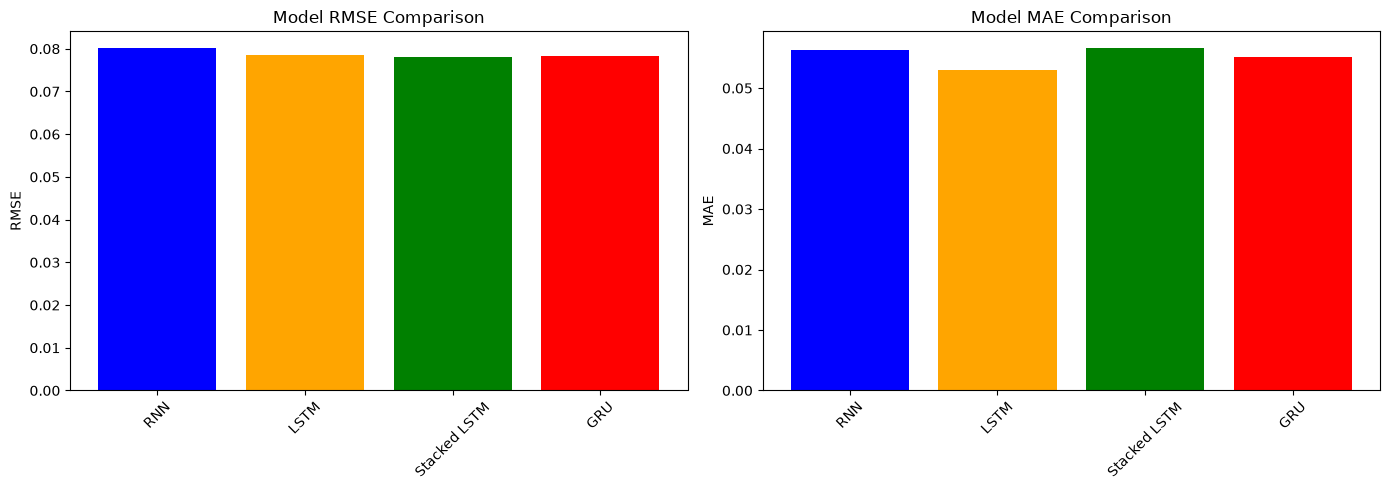

In [8]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'Stacked LSTM', 'GRU'],
    'RMSE': [rnn_rmse, lstm_rmse, stacked_lstm_rmse, gru_rmse],
    'MAE': [rnn_mae, lstm_mae, stacked_lstm_mae, gru_mae]
})

print("\nModel Comparison:")
print(comparison)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comparison['Model'], comparison['RMSE'], color=['blue', 'orange', 'green', 'red'])
axes[0].set_ylabel('RMSE')
axes[0].set_title('Model RMSE Comparison')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(comparison['Model'], comparison['MAE'], color=['blue', 'orange', 'green', 'red'])
axes[1].set_ylabel('MAE')
axes[1].set_title('Model MAE Comparison')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Training History Visualization

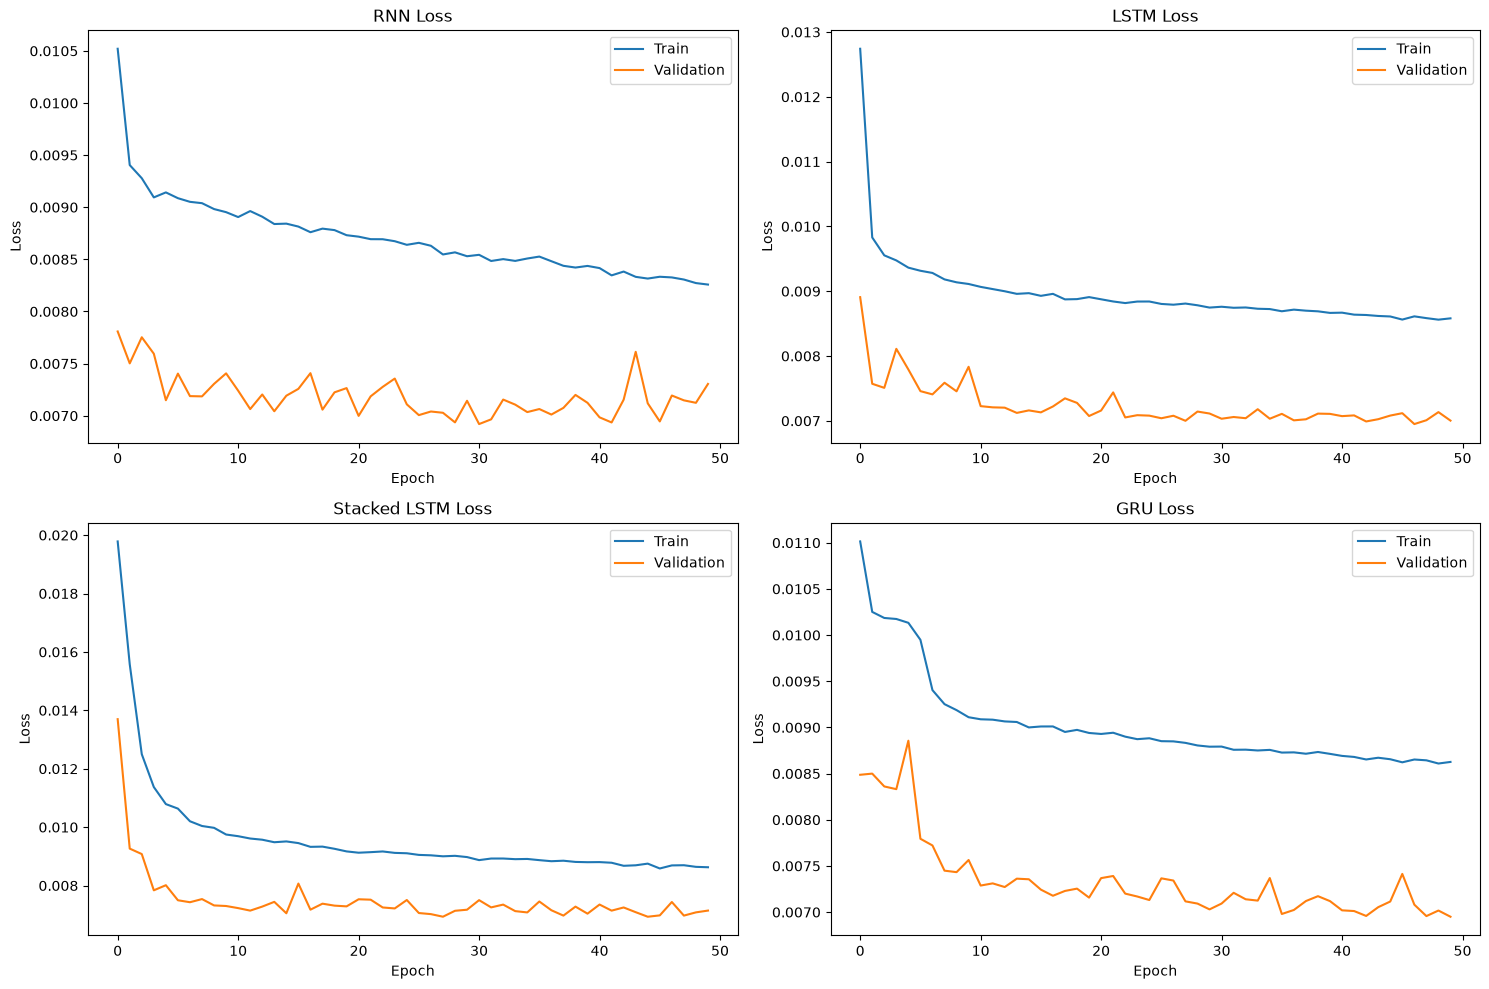

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# RNN
axes[0, 0].plot(rnn_history.history['loss'], label='Train')
axes[0, 0].plot(rnn_history.history['val_loss'], label='Validation')
axes[0, 0].set_title('RNN Loss')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()

# LSTM
axes[0, 1].plot(lstm_history.history['loss'], label='Train')
axes[0, 1].plot(lstm_history.history['val_loss'], label='Validation')
axes[0, 1].set_title('LSTM Loss')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()

# Stacked LSTM
axes[1, 0].plot(stacked_lstm_history.history['loss'], label='Train')
axes[1, 0].plot(stacked_lstm_history.history['val_loss'], label='Validation')
axes[1, 0].set_title('Stacked LSTM Loss')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()

# GRU
axes[1, 1].plot(gru_history.history['loss'], label='Train')
axes[1, 1].plot(gru_history.history['val_loss'], label='Validation')
axes[1, 1].set_title('GRU Loss')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 8. Predictions Visualization

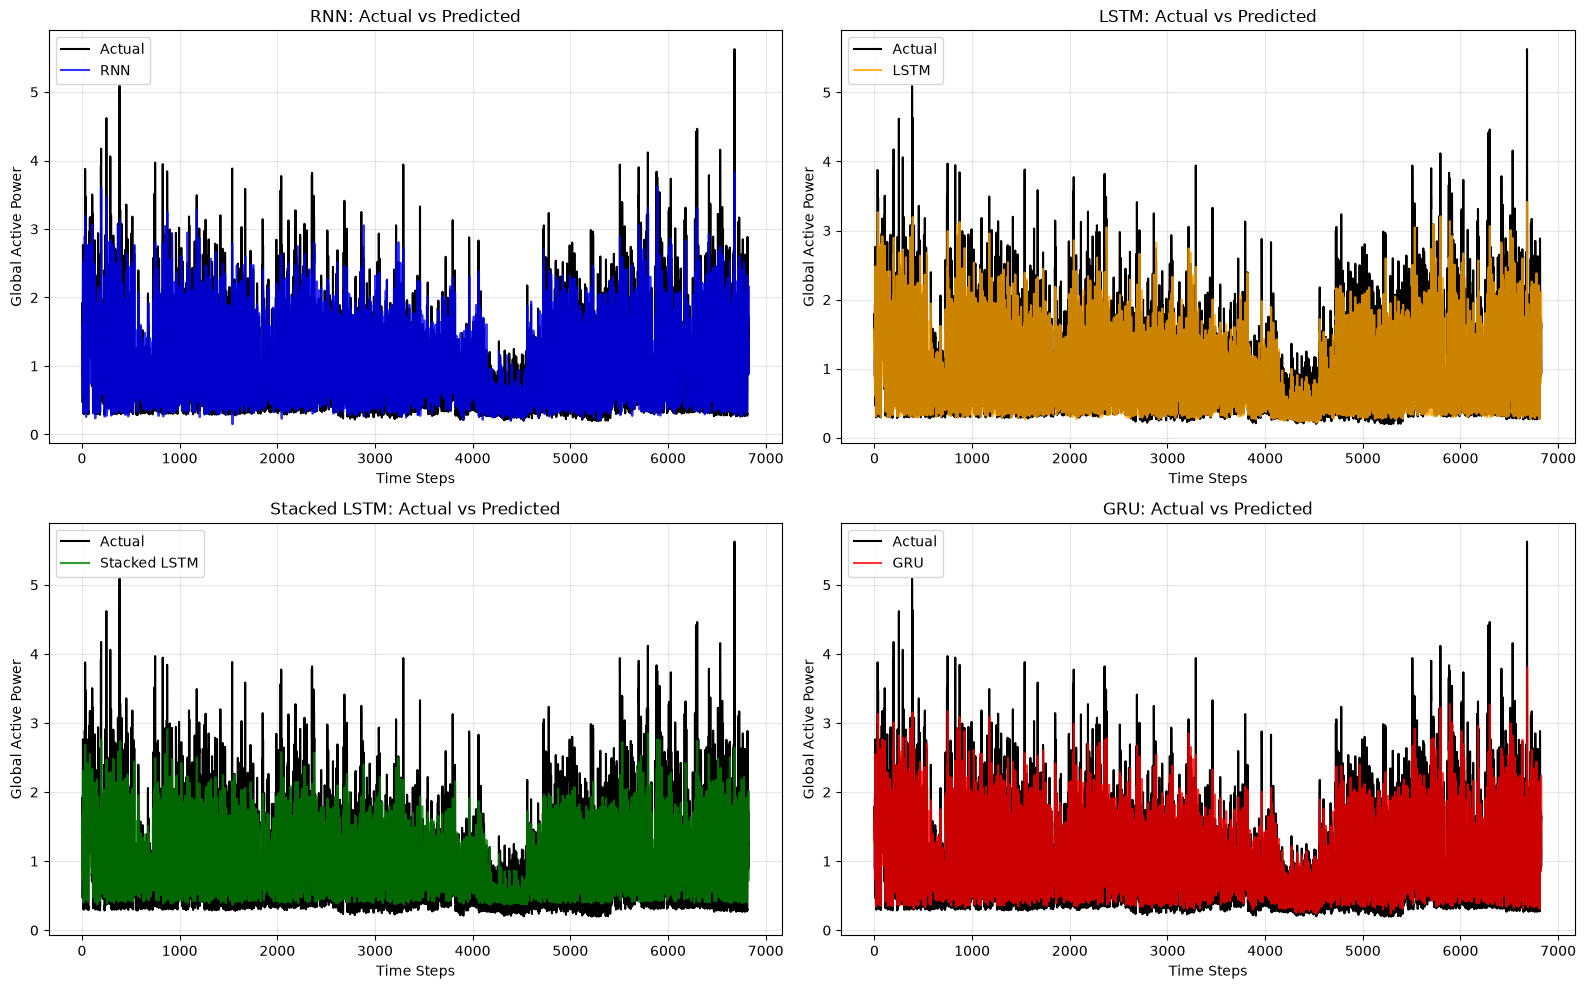

In [10]:
# Inverse transform predictions to original scale
rnn_pred_original = scaler.inverse_transform(rnn_pred)
lstm_pred_original = scaler.inverse_transform(lstm_pred)
stacked_lstm_pred_original = scaler.inverse_transform(stacked_lstm_pred)
gru_pred_original = scaler.inverse_transform(gru_pred)
y_test_original = scaler.inverse_transform(y_test)

# Plot each model's predictions separately
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(y_test_original, label='Actual', color='black', linewidth=1.5)
axes[0, 0].plot(rnn_pred_original, label='RNN', color='blue', alpha=0.8)
axes[0, 0].set_title('RNN: Actual vs Predicted')
axes[0, 0].set_xlabel('Time Steps')
axes[0, 0].set_ylabel('Global Active Power')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(y_test_original, label='Actual', color='black', linewidth=1.5)
axes[0, 1].plot(lstm_pred_original, label='LSTM', color='orange', alpha=0.8)
axes[0, 1].set_title('LSTM: Actual vs Predicted')
axes[0, 1].set_xlabel('Time Steps')
axes[0, 1].set_ylabel('Global Active Power')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(y_test_original, label='Actual', color='black', linewidth=1.5)
axes[1, 0].plot(stacked_lstm_pred_original, label='Stacked LSTM', color='green', alpha=0.8)
axes[1, 0].set_title('Stacked LSTM: Actual vs Predicted')
axes[1, 0].set_xlabel('Time Steps')
axes[1, 0].set_ylabel('Global Active Power')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(y_test_original, label='Actual', color='black', linewidth=1.5)
axes[1, 1].plot(gru_pred_original, label='GRU', color='red', alpha=0.8)
axes[1, 1].set_title('GRU: Actual vs Predicted')
axes[1, 1].set_xlabel('Time Steps')
axes[1, 1].set_ylabel('Global Active Power')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()